In [1]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler

import mne
from torch.utils.data import Dataset
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Defs

In [2]:
def normalize_tfr_robust(X, eps=1e-8):
    """
    Робастная нормализация TFR:
    - вместо среднего — медиана
    - вместо std — IQR (q75 - q25)
    - результат приводится к диапазону [0, 1]

    X shape: (N, C, F, T)
    Нормировка считается по train:
    медиана/квантили берутся по N и T → остаются (C, F)
    """

    # Медиана по trial и времени → (1, C, F, 1)
    median = np.median(X, axis=(0, 3), keepdims=True)

    # Квантили для IQR (робастной шкалы)
    q25 = np.percentile(X, 25, axis=(0, 3), keepdims=True)
    q75 = np.percentile(X, 75, axis=(0, 3), keepdims=True)
    iqr = (q75 - q25) + eps

    # Нормировка:
    # при медиана → 0.5, q25→0, q75→1
    X_norm = (X - median) / iqr + 0.5

    # Жёсткое ограничение диапазона
    # X_norm = np.clip(X_norm, 0.0, 1.0)

    return X_norm

In [3]:
class AlexNetTFR(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, dropout: float = 0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=(5,11), stride=(1,4), padding=(2,0)),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2,3), stride=(2,2)),

            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2,3), stride=(2,2)),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        self.adapt = nn.AdaptiveAvgPool2d((4, 8))  # фиксируем размер
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256 * 4 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adapt(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [4]:
from torch.utils.data import Dataset
import torch

class TFRDataset(Dataset):
    def __init__(self, X, y, time_crop=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.time_crop = time_crop  # int или None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]  # (C,F,T)
        if self.time_crop is not None:
            C, F, T = x.shape
            tc = self.time_crop
            if tc < T:
                t0 = torch.randint(0, T - tc + 1, (1,)).item()
                x = x[:, :, t0:t0+tc]
        return x, self.y[idx]


In [5]:
import optuna
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score

# ---- train/eval helpers ----

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    n = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)

        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        n += x.size(0)
    return total_loss / n


@torch.no_grad()
def eval_one_epoch_f1_macro(model, loader, device):
    model.eval()
    total_loss = 0.0
    n = 0

    all_pred = []
    all_true = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = F.cross_entropy(logits, y)

        total_loss += loss.item() * x.size(0)
        n += x.size(0)

        pred = logits.argmax(dim=1)
        all_pred.append(pred.cpu().numpy())
        all_true.append(y.cpu().numpy())

    val_loss = total_loss / n
    y_pred = np.concatenate(all_pred)
    y_true = np.concatenate(all_true)

    f1m = f1_score(y_true, y_pred, average="macro")
    return val_loss, f1m


# ---- objective ----
def make_objective(
    X, 
    y, 
    test_size, 
    seed, 
    device, 
    ModelCls, 
    in_channels=7, 
    num_classes=2, 
    max_epochs = 30, 
    patience = 6,     
    cv=False,                 # None/0 -> holdout, int -> kfold, или объект Splitter
    cv_aggregate="mean",     # "mean" | "median"
):

    X = np.asarray(X)
    y = np.asarray(y)

    # --- заранее готовим сплиты внутри генератора ---
    if cv :
        from sklearn.model_selection import StratifiedKFold

        splitter = StratifiedKFold(n_splits=max(2, int(round(1/test_size))), shuffle=True, random_state=seed)

        splits = []
        for fold_id, (tr_idx, va_idx) in enumerate(splitter.split(X, y)):
            splits.append((f"fold{fold_id}", X[tr_idx], y[tr_idx], X[va_idx], y[va_idx]))
        
    else:
        from sklearn.model_selection import train_test_split

        X_train, X_val, y_train, y_val = train_test_split(
            X, y,
            test_size=test_size,
            random_state=seed,
            stratify=y
        )
        splits = [("holdout", X_train, y_train, X_val, y_val)]
    
    def objective(trial):
        lr = trial.suggest_float("lr", 1e-5, 3e-3, log=True)
        wd = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
        dropout = trial.suggest_float("dropout", 0.0, 0.7)
        batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

        crop_on = trial.suggest_categorical("time_crop_on", [0, 1])
        time_crop = None

        fold_best_f1s = []
        fold_curves = []  # чтобы сохранять кривые по каждому фолду

        # --- прогоняем все сплиты (1 holdout или K фолдов) ---
        for split_name, X_train, y_train, X_val, y_val in splits:
            if crop_on:
                # X_train shape: (N, C, F, T) -> time dim = 3
                time_crop = trial.suggest_int("time_crop", 200, X_train.shape[3])

            train_ds = TFRDataset(X_train, y_train, time_crop=time_crop)
            val_ds   = TFRDataset(X_val,   y_val,   time_crop=None)

            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
            val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

            model = ModelCls(in_channels=in_channels, num_classes=num_classes, dropout=dropout).to(device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

            bad = 0
            best_f1 = -1.0
            train_losses, val_losses, val_f1s = [], [], []

            for epoch in range(max_epochs):
                tr_loss = train_one_epoch(model, train_loader, optimizer, device)
                va_loss, va_f1 = eval_one_epoch_f1_macro(model, val_loader, device)

                train_losses.append(tr_loss)
                val_losses.append(va_loss)
                val_f1s.append(va_f1)

                if va_f1 > best_f1:
                    best_f1 = va_f1
                    bad = 0
                else:
                    bad += 1
                    if bad >= patience:
                        break

            fold_best_f1s.append(best_f1)
            fold_curves.append({
                "split": split_name,
                "train_losses": train_losses,
                "val_losses": val_losses,
                "val_f1s": val_f1s,
            })

        # --- агрегируем метрику по фолдам ---
        if cv_aggregate == "median":
            score = float(np.median(fold_best_f1s))
        else:
            score = float(np.mean(fold_best_f1s))

        # report/prune: обычно репортят агрегированный score как один step
        trial.report(score, step=0)
        if trial.should_prune():
            raise optuna.TrialPruned()

        # сохраним детали
        trial.set_user_attr("fold_best_f1s", fold_best_f1s)
        trial.set_user_attr("fold_curves", fold_curves)
        trial.set_user_attr("cv_mode", "holdout" if (cv is None or cv == 0) else "kfold")

        return score

    return objective


# playground

In [6]:
time_frequency_file = "../tfr_s10.fif"
tfr = mne.time_frequency.read_tfrs(time_frequency_file)[0]
min_f, max_f, min_t, max_t = 5, 30, 100, -500
y = np.where(tfr.events[:, 2] == 9, 1, 0)
X = normalize_tfr_robust(tfr.copy().crop(tmin=0.0, tmax=1.0).data)[:, :, min_f:max_f, min_t:max_t]
device = "cuda" if torch.cuda.is_available() else "cpu"

Reading ../tfr_s10.fif ...


/tmp/ipykernel_2043657/2521578396.py:2: RuntimeWarning: This filename (../tfr_s10.fif) does not conform to MNE naming conventions. All tfr files should end with -tfr.h5 or _tfr.h5
  tfr = mne.time_frequency.read_tfrs(time_frequency_file)[0]


Not setting metadata


In [7]:
max_epochs = 100
num_classes = 2
channels = X.shape[1]
seed = 42
test_size = 0.2
n_trials_optuna_whole = 50
n_startup_trials, n_warmup_steps = 5, 5

In [38]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=seed),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=n_startup_trials, n_warmup_steps=n_warmup_steps),
)

objective = make_objective(
    X, 
    y, 
    test_size, 
    seed, 
    device = device,
    ModelCls = AlexNetTFR,   # твой класс модели
    in_channels = channels,
    num_classes = num_classes,
    max_epochs = max_epochs
)

study.optimize(objective, n_trials=n_trials_optuna_whole, show_progress_bar=True)

print("Best f1_macro:", study.best_value)
print("Best params:", study.best_params)

[I 2025-12-16 18:26:21,727] A new study created in memory with name: no-name-a2988df1-7fbb-4135-9d5b-6fad14fcecde


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-16 18:26:26,172] Trial 0 finished with value: 0.7210115684691956 and parameters: {'lr': 8.468008575248323e-05, 'weight_decay': 0.006351221010640704, 'dropout': 0.5123957592679835, 'batch_size': 16, 'time_crop_on': 1, 'time_crop': 321}. Best is trial 0 with value: 0.7210115684691956.
[I 2025-12-16 18:26:29,065] Trial 1 finished with value: 0.6497128794093519 and parameters: {'lr': 0.0005675206026988746, 'weight_decay': 1.2087541473056965e-06, 'dropout': 0.678936896513396, 'batch_size': 16, 'time_crop_on': 1, 'time_crop': 306}. Best is trial 0 with value: 0.7210115684691956.
[I 2025-12-16 18:26:30,626] Trial 2 finished with value: 0.7213114754098361 and parameters: {'lr': 0.00011748439548007026, 'weight_decay': 1.461896279370496e-05, 'dropout': 0.42829702630566563, 'batch_size': 64, 'time_crop_on': 1, 'time_crop': 240}. Best is trial 2 with value: 0.7213114754098361.
[I 2025-12-16 18:26:33,049] Trial 3 finished with value: 0.6983516483516483 and parameters: {'lr': 0.0001878542

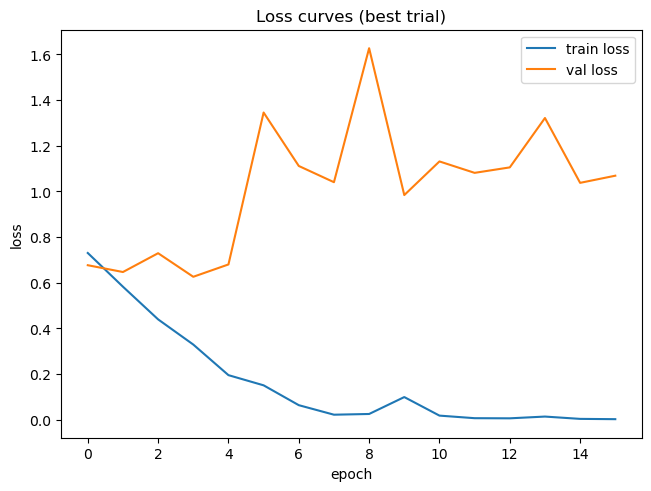

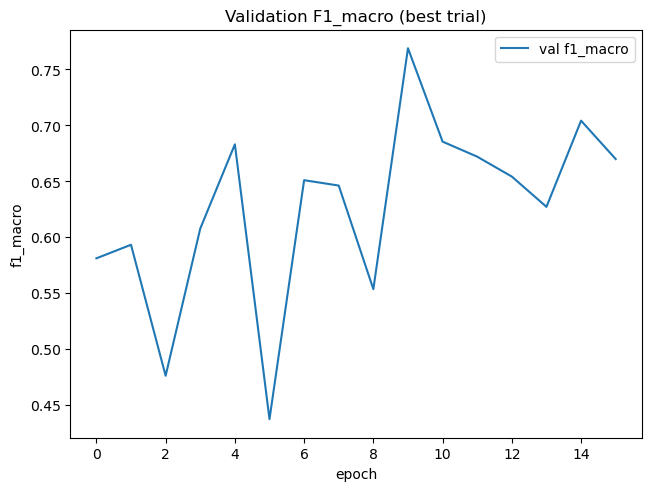

In [39]:
import matplotlib.pyplot as plt

best_trial = study.best_trial
train_losses = best_trial.user_attrs.get("train_losses", [])
val_losses   = best_trial.user_attrs.get("val_losses", [])
val_f1s      = best_trial.user_attrs.get("val_f1s", [])

plt.figure(constrained_layout=True)
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Loss curves (best trial)")
plt.show()

plt.figure(constrained_layout=True)
plt.plot(val_f1s, label="val f1_macro")
plt.xlabel("epoch")
plt.ylabel("f1_macro")
plt.legend()
plt.title("Validation F1_macro (best trial)")
plt.show()

In [8]:
import numpy as np

# X: (N, C, F, T) = (302, 7, 25, 401)
dim = X.shape
X_flat = np.reshape(X, (dim[0], dim[1]*dim[2]*dim[3]))  # (302, 70175)

# y: (N,) 0/1
y = y.astype(np.int64)


In [9]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.decomposition import PCA

def svm_objective(trial):
    model_type = trial.suggest_categorical("model", ["linear", "rbf"])

    # (опционально) PCA для ускорения/стабилизации, особенно важно для rbf
    use_pca = trial.suggest_categorical("pca", [0, 1])
    pca_n = None
    if use_pca:
        # безопасные диапазоны для 302 семплов
        pca_var = trial.suggest_float("pca_var", 0.8, 0.95)

    if model_type == "linear":
        C = trial.suggest_float("C", 1e-3, 1e3, log=True)
        clf = LinearSVC(C=C, class_weight="balanced", max_iter=20000)
    else:
        C = trial.suggest_float("C", 1e-2, 1e3, log=True)
        gamma = trial.suggest_float("gamma", 1e-6, 1e-1, log=True)
        clf = SVC(C=C, gamma=gamma, kernel="rbf", class_weight="balanced")

    steps = []
    if use_pca:
        steps.append(("pca", PCA(n_components=pca_var, random_state=42)))
    steps.append(("clf", clf))

    pipe = Pipeline(steps)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # F1_macro
    scores = cross_val_score(pipe, X_flat, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    return float(scores.mean())

study_svm = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_svm.optimize(svm_objective, n_trials=50, show_progress_bar=True)

print("Best CV f1_macro:", study_svm.best_value)
print("Best params:", study_svm.best_params)


[I 2025-12-17 12:41:46,855] A new study created in memory with name: no-name-0fd8f4a3-6b4f-4f50-8661-ef2fec084efb


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-17 12:42:12,891] Trial 0 finished with value: 0.40293928505356985 and parameters: {'model': 'rbf', 'pca': 0, 'C': 0.06026889128682508, 'gamma': 6.025215736203862e-06}. Best is trial 0 with value: 0.40293928505356985.
[I 2025-12-17 12:42:37,364] Trial 1 finished with value: 0.343919887450152 and parameters: {'model': 'rbf', 'pca': 1, 'pca_var': 0.8030876741443704, 'C': 707.2114131472224, 'gamma': 0.014528246637516038}. Best is trial 0 with value: 0.40293928505356985.
[I 2025-12-17 12:43:02,471] Trial 2 finished with value: 0.6105536365299817 and parameters: {'model': 'linear', 'pca': 1, 'pca_var': 0.8787134647448357, 'C': 0.3905441275210791}. Best is trial 2 with value: 0.6105536365299817.
[I 2025-12-17 12:43:27,392] Trial 3 finished with value: 0.35609760166873705 and parameters: {'model': 'rbf', 'pca': 1, 'pca_var': 0.8549542764940538, 'C': 1.9069966103000422, 'gamma': 0.008431013932082471}. Best is trial 2 with value: 0.6105536365299817.
[I 2025-12-17 12:43:48,407] Trial 4

In [10]:
from optuna.visualization import plot_optimization_history, plot_param_importances

plot_optimization_history(study_svm).show()
plot_param_importances(study_svm).show()


In [14]:
import pandas as pd

df = study_svm.trials_dataframe(
    attrs=("number", "value", "state", "params")
)


In [15]:
param_cols = [c for c in df.columns if c.startswith("params_")]

summary = {}
for c in param_cols:
    summary[c] = {
        "non_nan": df[c].notna().sum(),
        "unique": df[c].nunique(dropna=True),
        "min": df[c].min(),
        "max": df[c].max(),
    }

summary_df = pd.DataFrame(summary).T
print(summary_df)


               non_nan unique       min         max
params_C          50.0   50.0  0.001074  707.211413
params_gamma      12.0   12.0  0.000003    0.070457
params_model        50      2    linear         rbf
params_pca          50      2         0           1
params_pca_var    11.0   11.0  0.803088    0.945755


In [16]:
numeric_params = summary_df.index[
    summary_df["unique"] > 1
]

corrs = {}
for p in numeric_params:
    col = p
    if df[col].dtype.kind in "if":
        valid = df[[col, "value"]].dropna()
        if len(valid) > 3:
            corrs[p] = valid[col].corr(valid["value"])

corr_df = pd.Series(corrs).sort_values(ascending=False)
print(corr_df)


params_pca_var   -0.023398
params_gamma     -0.231341
params_C         -0.291974
params_pca       -0.687111
dtype: float64


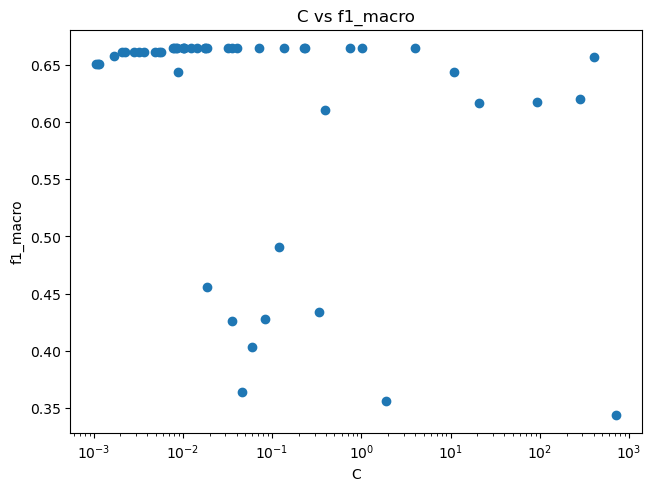

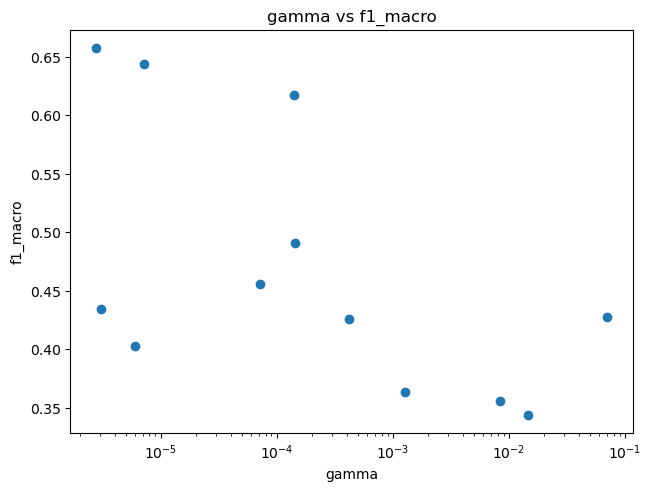

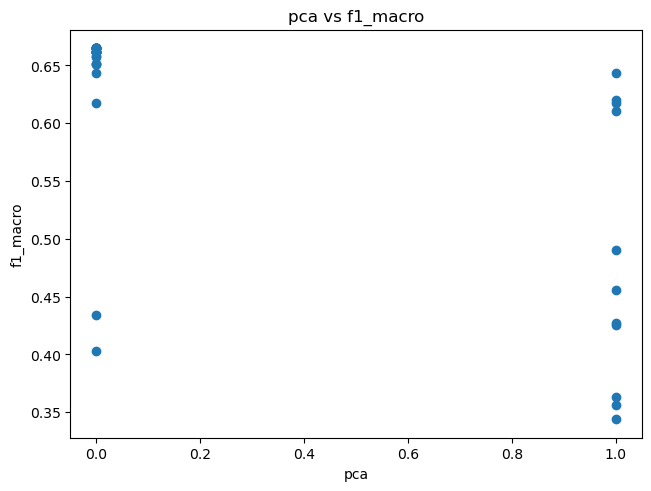

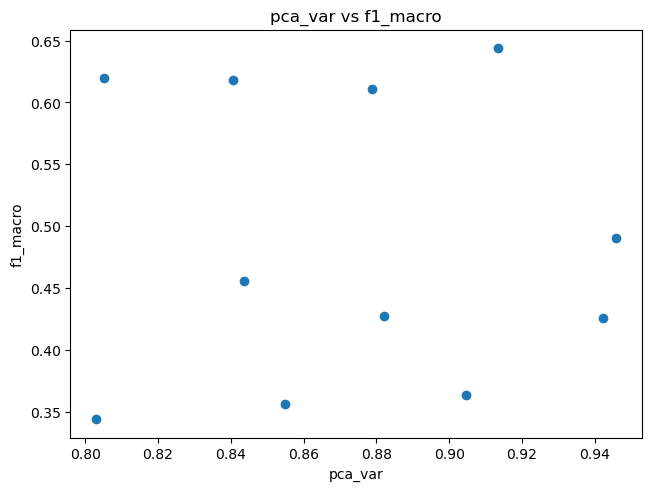

In [17]:
import matplotlib.pyplot as plt
import numpy as np

for p in param_cols:
    if df[p].dtype.kind not in "if":
        continue

    valid = df[[p, "value"]].dropna()
    if len(valid) < 5:
        continue

    plt.figure(constrained_layout=True)
    plt.scatter(valid[p], valid["value"])

    # лог-шкала для scale-параметров
    if valid[p].min() > 0 and valid[p].max() / valid[p].min() > 50:
        plt.xscale("log")

    plt.xlabel(p.replace("params_", ""))
    plt.ylabel("f1_macro")
    plt.title(f"{p.replace('params_', '')} vs f1_macro")
    plt.show()



In [21]:
top = df.sort_values("value", ascending=False).head(40)
pd.set_option("display.max_columns", None)
print(top)


    number     value     state    params_C  params_gamma params_model  \
15      15  0.664860  COMPLETE    0.010136           NaN       linear   
14      14  0.664860  COMPLETE    0.007780           NaN       linear   
41      41  0.664860  COMPLETE    0.008408           NaN       linear   
31      31  0.664860  COMPLETE    0.012248           NaN       linear   
47      47  0.664860  COMPLETE    0.007949           NaN       linear   
42      42  0.664860  COMPLETE    0.010304           NaN       linear   
32      32  0.664860  COMPLETE    0.008523           NaN       linear   
20      20  0.664860  COMPLETE    0.010260           NaN       linear   
16      16  0.664838  COMPLETE    0.018482           NaN       linear   
19      19  0.664838  COMPLETE    3.958918           NaN       linear   
18      18  0.664838  COMPLETE    0.017599           NaN       linear   
22      22  0.664838  COMPLETE    0.071325           NaN       linear   
24      24  0.664838  COMPLETE    0.232718         

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_flat)

print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained:", pca.explained_variance_ratio_.sum())


Explained variance: [0.496937   0.06911091]
Total explained: 0.5660479106704343


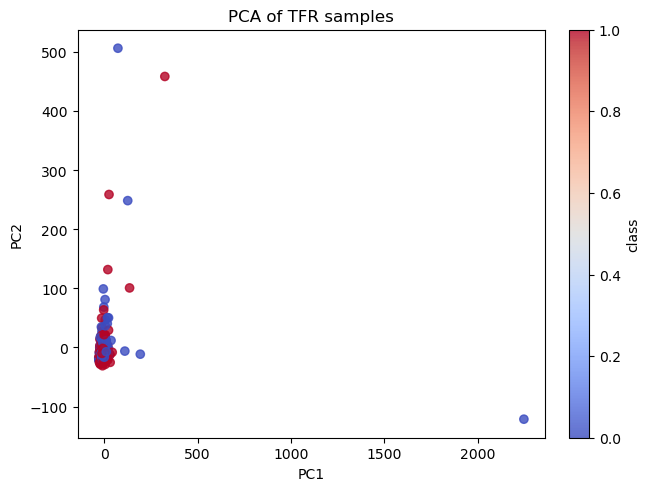

In [24]:
plt.figure(constrained_layout=True)
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y, cmap="coolwarm", alpha=0.8
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of TFR samples")
plt.colorbar(label="class")
plt.show()


In [25]:
from sklearn.manifold import TSNE

# обычно сначала PCA до 30–50 компонент
pca_50 = PCA(n_components=50, random_state=42)
X_pca_50 = pca_50.fit_transform(X_flat)

tsne = TSNE(
    n_components=2,
    perplexity=30,      # 20–50 при N=302
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca_50)


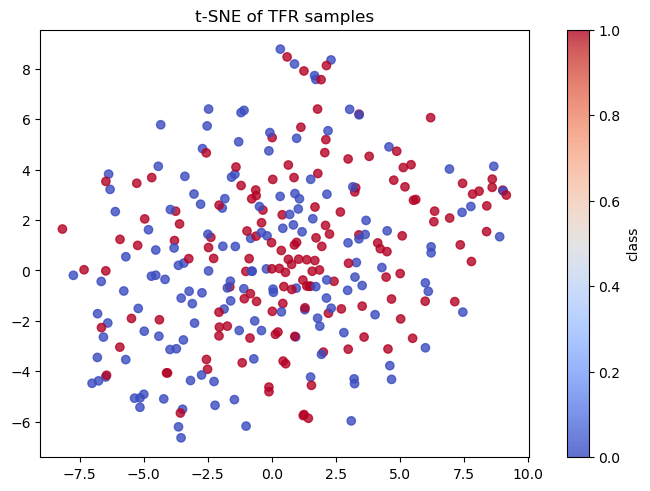

In [26]:
plt.figure(constrained_layout=True)
plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=y, cmap="coolwarm", alpha=0.8
)
plt.title("t-SNE of TFR samples")
plt.colorbar(label="class")
plt.show()


In [27]:
import umap

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,   # 10–30
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

X_umap = umap_model.fit_transform(X_pca_50)


/home/asma.benachour/miniconda3/envs/brainbert/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/asma.benachour/miniconda3/envs/brainbert/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



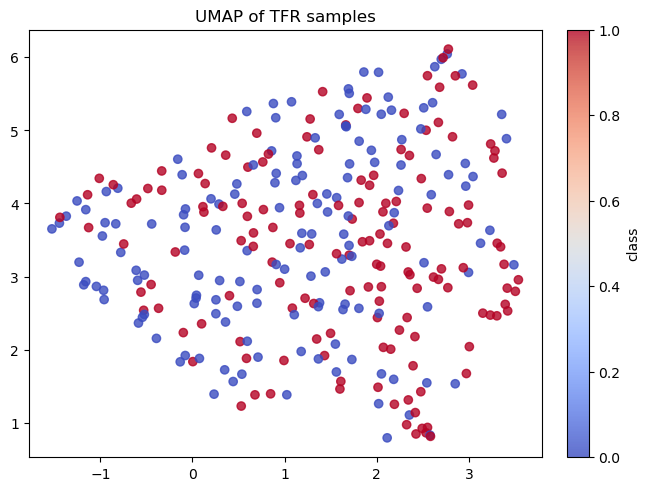

In [28]:
plt.figure(constrained_layout=True)
plt.scatter(
    X_umap[:, 0], X_umap[:, 1],
    c=y, cmap="coolwarm", alpha=0.8
)
plt.title("UMAP of TFR samples")
plt.colorbar(label="class")
plt.show()


In [31]:
import numpy as np
from sklearn.model_selection import train_test_split

idx = np.arange(len(y))

train_indices, val_indices = train_test_split(
    idx,
    test_size=0.2,
    random_state=42,
    stratify=y
)

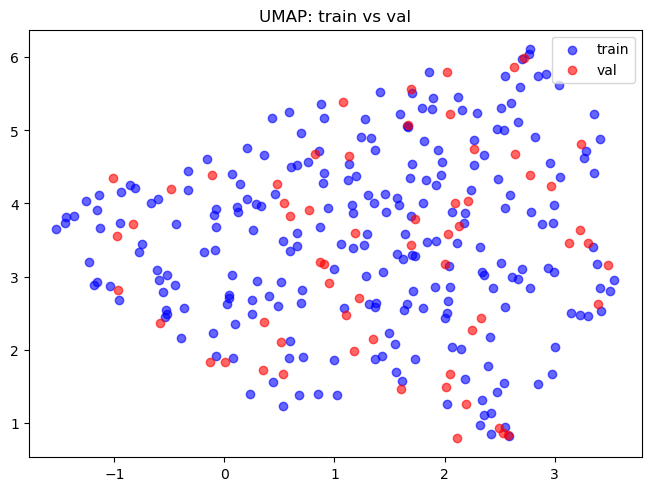

In [32]:
mask_train = np.isin(np.arange(len(y)), train_indices)

plt.figure(constrained_layout=True)
plt.scatter(X_umap[mask_train,0], X_umap[mask_train,1], c="blue", label="train", alpha=0.6)
plt.scatter(X_umap[~mask_train,0], X_umap[~mask_train,1], c="red", label="val", alpha=0.6)
plt.legend()
plt.title("UMAP: train vs val")
plt.show()


In [34]:
def loss_slope(losses):
    # линейный тренд: loss ~ a*epoch + b, хотим a < 0, и чем меньше (более отрицательно) — тем лучше
    e = np.arange(len(losses), dtype=np.float64)
    return float(np.polyfit(e, np.array(losses, dtype=np.float64), 1)[0])

In [33]:
# ---- objective ----
def make_multi_objective(X_train, y_train, X_val, y_val, device, ModelCls, in_channels=7, num_classes=2, max_epochs = 30, patience = 6):

    def objective(trial):
        lr = trial.suggest_float("lr", 1e-5, 3e-3, log=True)
        wd = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
        dropout = trial.suggest_float("dropout", 0.0, 0.7)
        batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

        # (опционально) random time crop
        crop_on = trial.suggest_categorical("time_crop_on", [0, 1])
        time_crop = None
        if crop_on:
            time_crop = trial.suggest_int("time_crop", 200, X_train.shape[3])  # 200..401

        train_ds = TFRDataset(X_train, y_train, time_crop=time_crop)
        val_ds   = TFRDataset(X_val, y_val, time_crop=None)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

        model = ModelCls(in_channels=in_channels, num_classes=num_classes, dropout=dropout).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        
        bad = 0
        train_losses, val_losses, val_f1s = [], [], []
        best_f1 = -1.0

        for epoch in range(max_epochs):
            tr_loss = train_one_epoch(model, train_loader, optimizer, device)
            va_loss, va_f1 = eval_one_epoch_f1_macro(model, val_loader, device)

            train_losses.append(tr_loss)
            val_losses.append(va_loss)
            val_f1s.append(va_f1)

            if va_f1 > best_f1:
                best_f1 = va_f1
                bad = 0
            else:
                bad += 1
                if bad >= patience:
                    break

        # slope по хвосту (стабильнее)
        tail = val_losses[-10:] if len(val_losses) >= 10 else val_losses
        slope = loss_slope(tail)

        trial.set_user_attr("train_losses", train_losses)
        trial.set_user_attr("val_losses", val_losses)
        trial.set_user_attr("val_f1s", val_f1s)
        trial.set_user_attr("val_loss_slope", slope)

        # Multi-objective: (maximize F1, minimize slope)
        return float(best_f1), float(slope)

    return objective

In [37]:
study = optuna.create_study(
    directions=["maximize", "minimize"],
    sampler=optuna.samplers.TPESampler(seed=seed),
    # pruner=optuna.pruners.MedianPruner(n_startup_trials=n_startup_trials, n_warmup_steps=n_warmup_steps) # может вызвать ошибки, так как прунер настроен на одиночную метрику
)

objective = make_multi_objective(
    X_train, y_train, X_val, y_val,
    device = device,
    ModelCls = AlexNetTFR,   # твой класс модели
    in_channels = channels,
    num_classes = num_classes,
    max_epochs = max_epochs
)

study.optimize(objective, n_trials=n_trials_optuna_whole, show_progress_bar=True)

pareto = study.best_trials
print("Pareto trials:", len(pareto))

for t in pareto[:10]:
    f1, slope = t.values
    print(f"trial={t.number} f1={f1:.4f} slope={slope:.6f} params={t.params}")


[I 2025-12-17 16:42:29,341] A new study created in memory with name: no-name-86bd72d1-6197-431c-9fcc-69e61008b691


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-17 16:42:32,648] Trial 0 finished with values: [0.7164342357123326, 0.012268530638491532] and parameters: {'lr': 8.468008575248323e-05, 'weight_decay': 0.006351221010640704, 'dropout': 0.5123957592679835, 'batch_size': 16, 'time_crop_on': 1, 'time_crop': 321}.
[I 2025-12-17 16:42:34,068] Trial 1 finished with values: [0.6392473118279569, -0.01702287996727258] and parameters: {'lr': 0.0005675206026988746, 'weight_decay': 1.2087541473056965e-06, 'dropout': 0.678936896513396, 'batch_size': 16, 'time_crop_on': 1, 'time_crop': 306}.
[I 2025-12-17 16:42:35,539] Trial 2 finished with values: [0.6677559912854031, 0.16283860206604] and parameters: {'lr': 0.00011748439548007026, 'weight_decay': 1.461896279370496e-05, 'dropout': 0.42829702630566563, 'batch_size': 64, 'time_crop_on': 1, 'time_crop': 240}.
[I 2025-12-17 16:42:37,169] Trial 3 finished with values: [0.655367231638418, 0.1263962687806726] and parameters: {'lr': 0.00018785426399210597, 'weight_decay': 0.00023423849847112912,

Trial number: 8
Values (f1, slope): [0.6712056737588652, -0.006085746577291773]
Params: {'lr': 3.106296006733529e-05, 'weight_decay': 1.0521761868451139e-06, 'dropout': 0.5708229999183839, 'batch_size': 64, 'time_crop_on': 1, 'time_crop': 223}


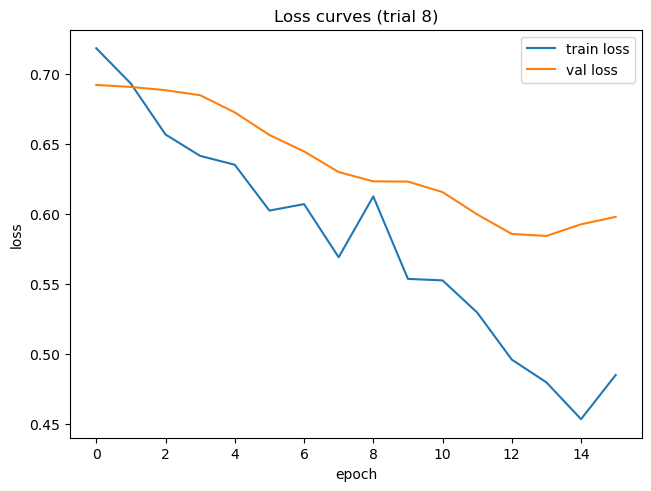

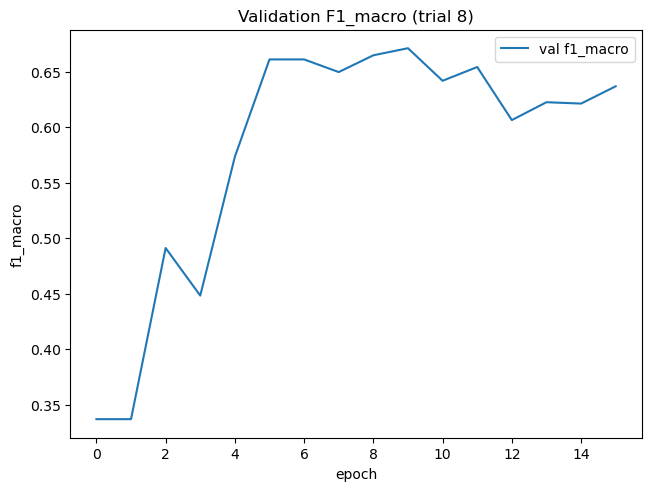

In [41]:
import matplotlib.pyplot as plt

t = study.get_trials(deepcopy=False)[8]   # если trials идут по номеру; надёжнее так:
# t = study.trials[8]

print("Trial number:", t.number)
print("Values (f1, slope):", t.values)
print("Params:", t.params)

train_losses = t.user_attrs.get("train_losses", [])
val_losses   = t.user_attrs.get("val_losses", [])
val_f1s      = t.user_attrs.get("val_f1s", [])

plt.figure(constrained_layout=True)
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"Loss curves (trial {t.number})")
plt.legend()
plt.show()

plt.figure(constrained_layout=True)
plt.plot(val_f1s, label="val f1_macro")
plt.xlabel("epoch")
plt.ylabel("f1_macro")
plt.title(f"Validation F1_macro (trial {t.number})")
plt.legend()
plt.show()
